In [ ]:
from jobflow import JobStore, run_locally
from maggma.stores import MemoryStore
from pymatgen.core import Structure
from fireworks import LaunchPad
from jobflow.managers.fireworks import flow_to_workflow
from atomate2.vasp.flows.qha import QhaMaker

from atomate2.forcefields.jobs import ForceFieldRelaxMaker
from atomate2.forcefields.jobs import ForceFieldStaticMaker
from atomate2.forcefields.flows.phonons import PhononMaker

si_structure = Structure.from_file("Si.cif")

pet_mad_calculator = {"@module": "upet.calculator", "@callable": "UPETCalculator", }
pet_mad_kwargs = {"device": "cpu", "rotational_average_order": 3, "model": "pet-mad-s", "version": "1.5.0"}  # change to "cuda" on GPU nodes
pet_mad_calculator="UPET"
bulk_relax_maker_petmad = ForceFieldRelaxMaker(
    force_field_name=pet_mad_calculator,
    relax_cell=True,
    relax_kwargs={"fmax": 0.0001},
    calculator_kwargs=pet_mad_kwargs,
)
bulk_relax_maker_petmad_cv = ForceFieldRelaxMaker(
    force_field_name=pet_mad_calculator,
    relax_cell=False,
    relax_kwargs={"fmax": 0.0001},
    calculator_kwargs=pet_mad_kwargs,
)

phonon_displacement_maker_petmad = ForceFieldStaticMaker(
    force_field_name=pet_mad_calculator,
    calculator_kwargs=pet_mad_kwargs,
)
phonon_displacement_maker_petmad.name = "pet-mad phonon static"

flow_petmad = QhaMaker(
    initial_relax_maker=bulk_relax_maker_petmad,
    eos_relax_maker=bulk_relax_maker_petmad_cv,
    min_length=10,
    phonon_maker=PhononMaker(
        generate_frequencies_eigenvectors_kwargs={
            "tmin": 0,
            "tmax": 500,
            "tstep": 10,
        },
        bulk_relax_maker=None,
        born_maker=None,
        static_energy_maker=phonon_displacement_maker_petmad,
        phonon_displacement_maker=phonon_displacement_maker_petmad,
    ),
    linear_strain=(-0.1, 0.1),
    number_of_frames=16,
    pressure=None,
    t_max=None,
    ignore_imaginary_modes=False,
    skip_analysis=False,
    eos_type="vinet",
).make(structure=si_structure)
workflow = flow_to_workflow(flow_petmad)
launchpad = LaunchPad.from_file("../my_launchpad.yaml")
launchpad.add_wf(workflow)



2026-03-04 02:10:10,014 INFO Added a workflow. id_map: {-117: 675, -116: 676, -115: 677, -114: 678, -113: 679, -112: 680, -111: 681, -110: 682, -109: 683, -108: 684, -107: 685, -106: 686, -105: 687, -104: 688, -103: 689, -102: 690, -101: 691, -100: 692, -99: 693, -98: 694, -97: 695}


{-117: 675,
 -116: 676,
 -115: 677,
 -114: 678,
 -113: 679,
 -112: 680,
 -111: 681,
 -110: 682,
 -109: 683,
 -108: 684,
 -107: 685,
 -106: 686,
 -105: 687,
 -104: 688,
 -103: 689,
 -102: 690,
 -101: 691,
 -100: 692,
 -99: 693,
 -98: 694,
 -97: 695}

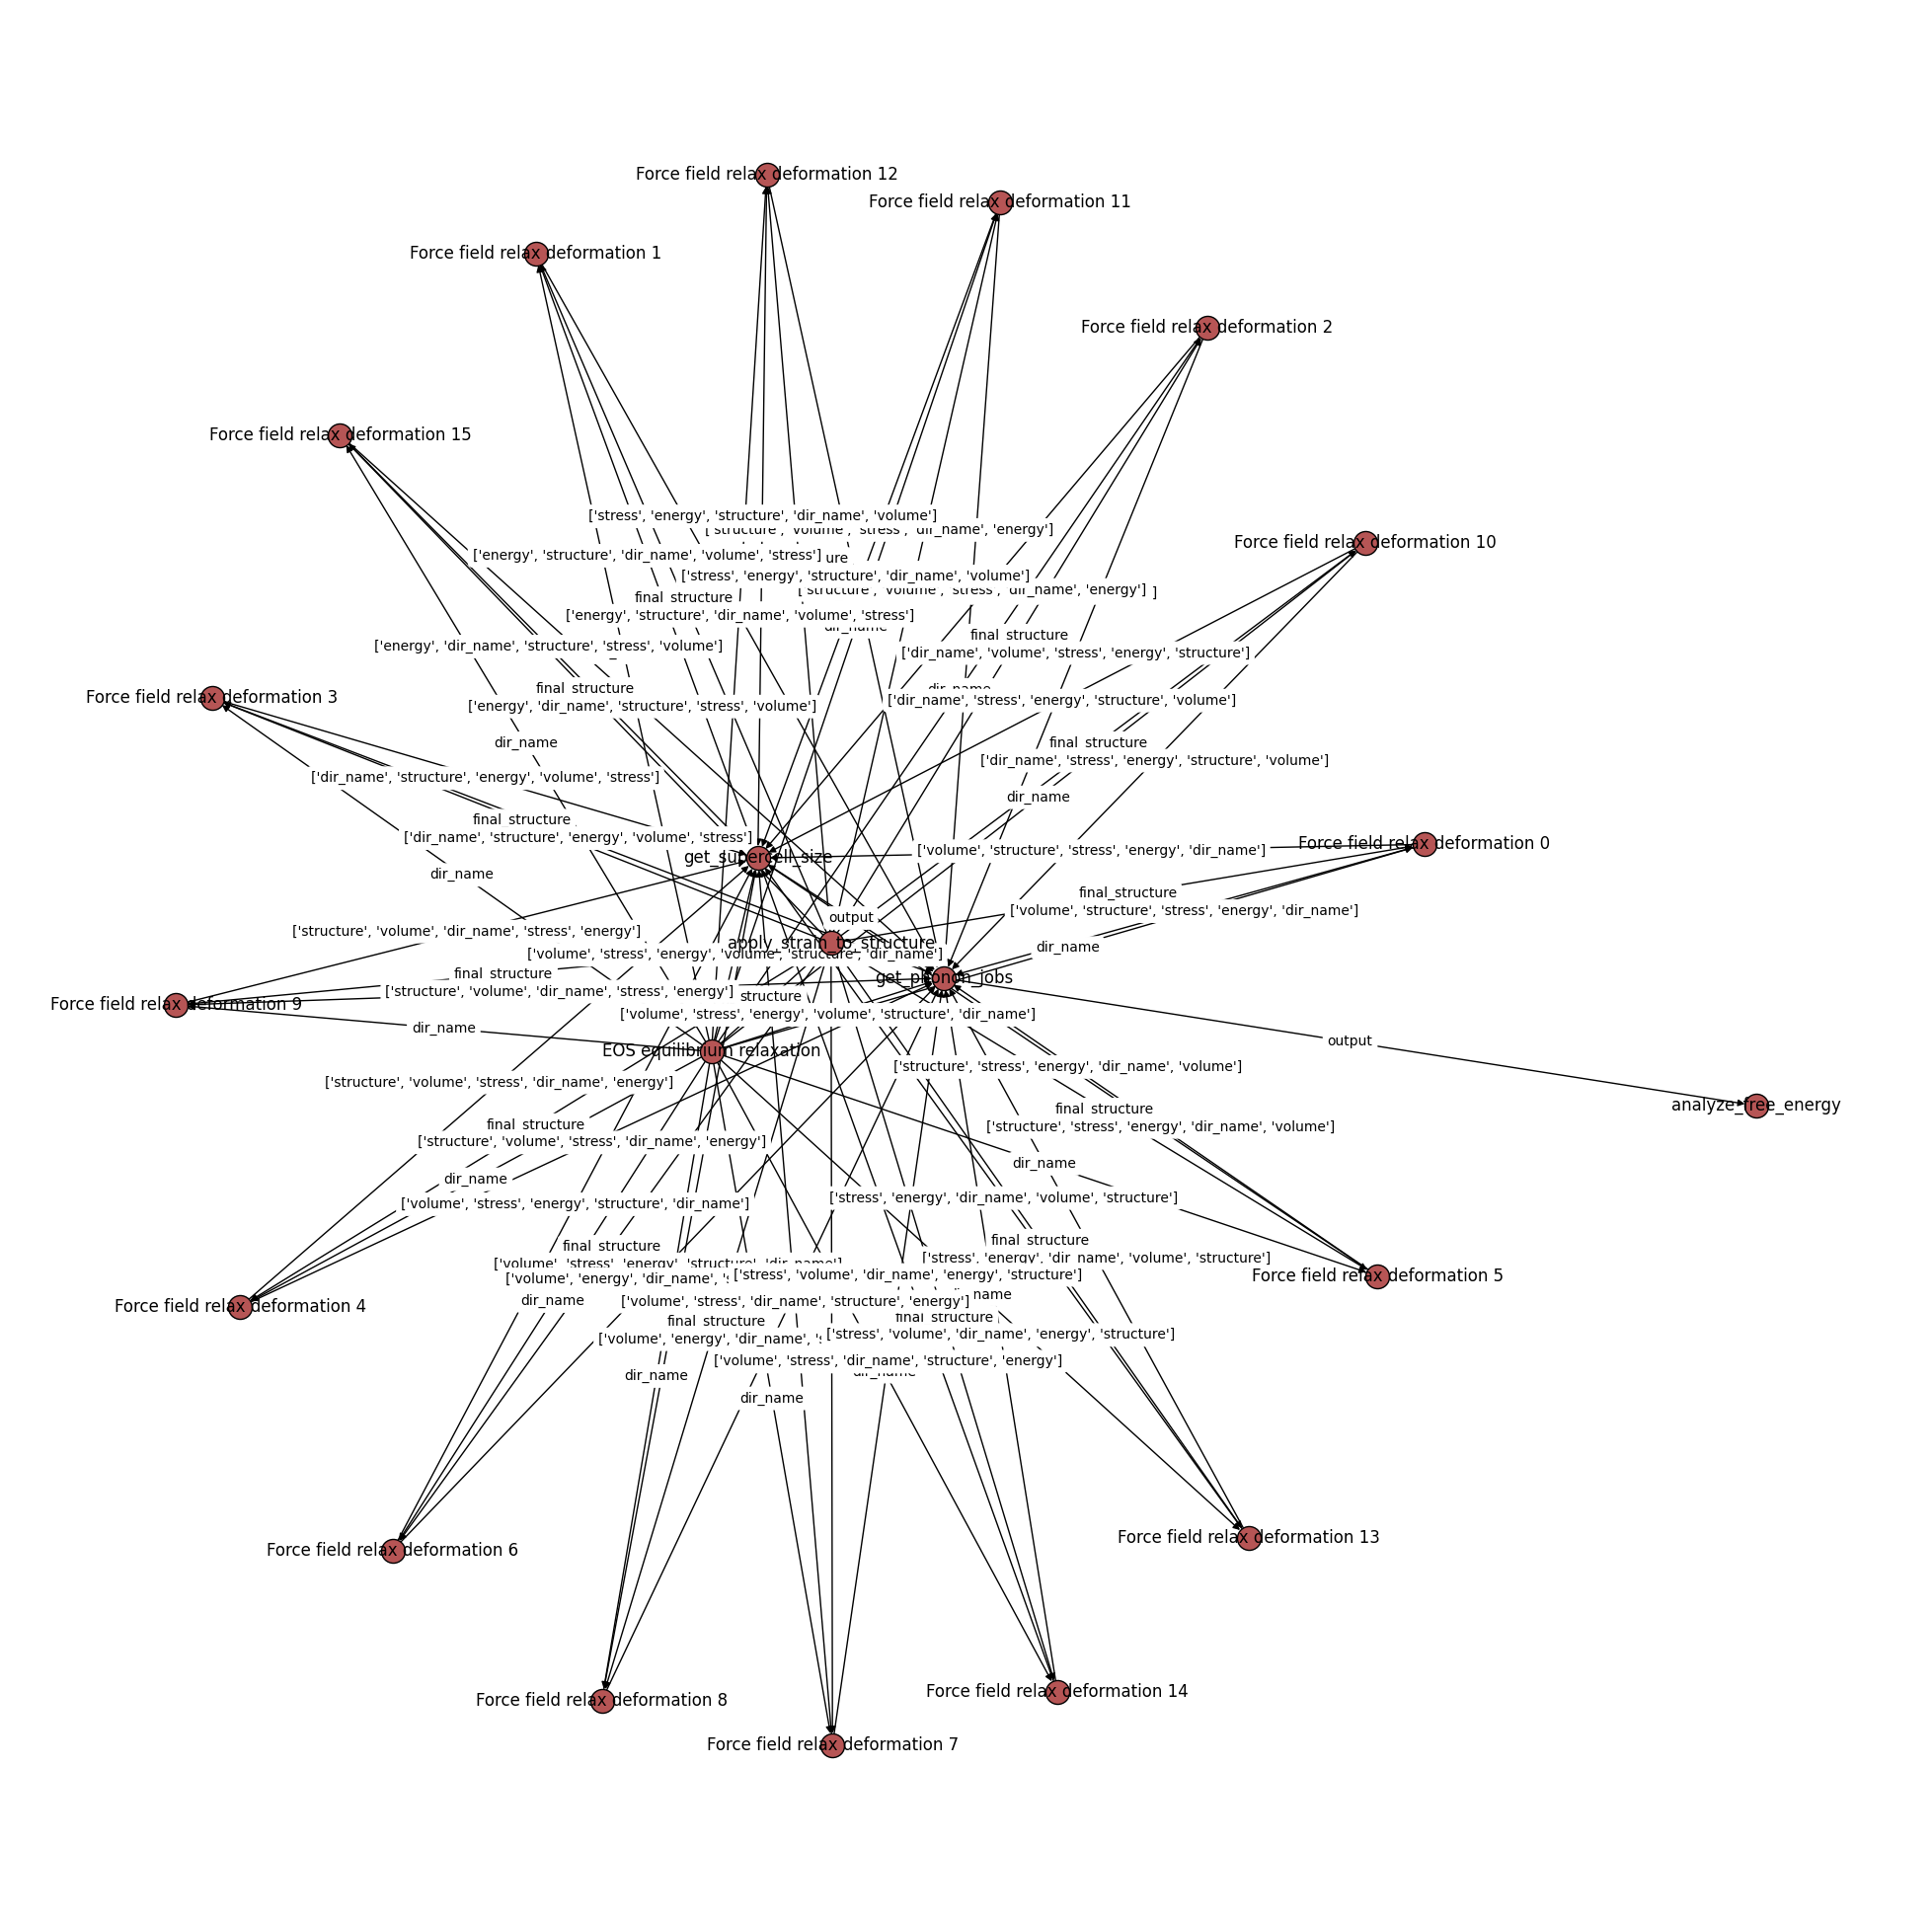

In [40]:
import networkx as nx
flow.draw_graph(figsize=(25, 25), layout_function=nx.nx_agraph.graphviz_layout).show()

In [ ]:

bulk_relax_maker = ForceFieldRelaxMaker(force_field_name="MACE_MPA_0", relax_cell=True, relax_kwargs={"fmax": 0.0001}, calculator_kwargs={"model_type": "MACE"})
bulk_relax_maker_constant_volume = ForceFieldRelaxMaker(force_field_name="MACE_MPA_0", relax_cell=False,  relax_kwargs={"fmax": 0.0001}, calculator_kwargs={"model_type": "MACE"})

phonon_displacement_maker = ForceFieldStaticMaker(force_field_name="MACE_MPA_0",calculator_kwargs={"model_type": "MACE"})
phonon_displacement_maker.name = "mace phonon static"
flow = QhaMaker(
    initial_relax_maker=bulk_relax_maker,
    eos_relax_maker=bulk_relax_maker_constant_volume,
    min_length=10,
    phonon_maker=PhononMaker(
        generate_frequencies_eigenvectors_kwargs={
            "tmin": 0,
            "tmax": 500,
            "tstep": 10,
        },
        bulk_relax_maker=None,
        born_maker=None,
        static_energy_maker=phonon_displacement_maker,
        phonon_displacement_maker=phonon_displacement_maker,
    ),
    linear_strain=(-0.1, 0.1),
    number_of_frames=16,
    pressure=None,
    t_max=None,
    ignore_imaginary_modes=False,
    skip_analysis=False,
    eos_type="vinet",
).make(structure=si_structure)
workflow = flow_to_workflow(flow)
launchpad = LaunchPad.from_file("../my_launchpad.yaml")
launchpad.add_wf(workflow)

In [42]:
import yaml
from maggma.stores import MongoURIStore
from maggma.stores.gridfs import GridFSURIStore
from jobflow.core.store import JobStore

from pymatgen.electronic_structure.plotter import DosPlotter, BSPlotter
from pymatgen.electronic_structure.dos import CompleteDos
from pymatgen.electronic_structure.bandstructure import BandStructureSymmLine

# Read connection URIs from the config file
with open("../jobflow.yaml") as f:
    jf_config = yaml.safe_load(f)

# The GridFS data-store creates its own MongoClient lazily; the server we have at the moment
# can time out while fetching large QHA blobs.
timeout_kwargs = {"serverSelectionTimeoutMS": 120_000, "socketTimeoutMS": 300_000}

docs_store = MongoURIStore(
    uri=jf_config["JOB_STORE"]["docs_store"]["uri"],
    collection_name="outputs",
    mongoclient_kwargs=timeout_kwargs,
)
data_store = GridFSURIStore(
    uri=jf_config["JOB_STORE"]["additional_stores"]["data"]["uri"],
    collection_name="outputs_blobs",
    mongoclient_kwargs=timeout_kwargs,
)
store = JobStore(docs_store=docs_store, additional_stores={"data": data_store})
store.connect()

result = store.query_one(
    {"name": "analyze_free_energy"},
    properties=[
        "output"
    ],
    load=True,
    sort={"completed_at": -1},
)

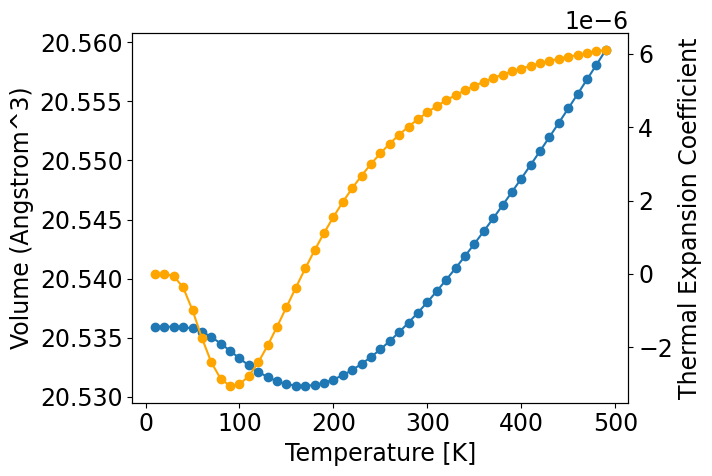

In [44]:
plt.plot(result['output']['temperatures'][1:], result['output']['volume_temperature'], marker="o")
plt.xlabel("Temperature [K]")
plt.ylabel("Volume (Angstrom^3)")
ax2 = plt.gca().twinx()
ax2.plot(result['output']['temperatures'][1:], result['output']['thermal_expansion'], marker="o", color="orange")
ax2.set_ylabel("Thermal Expansion Coefficient")
plt.show()

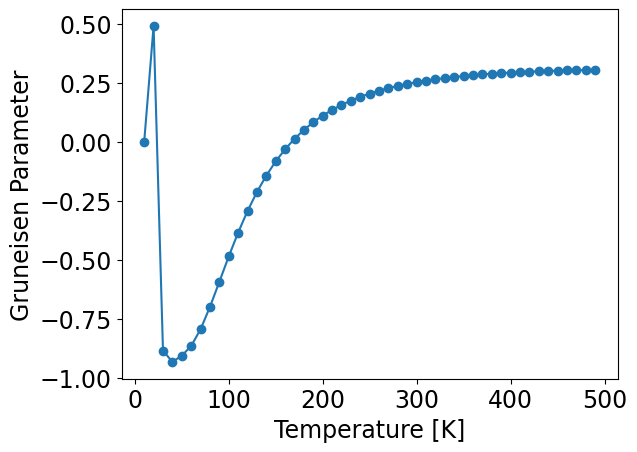

In [39]:
plt.plot(result['output']['temperatures'][1:], result['output']['gruneisen_temperature'], marker="o")
plt.xlabel("Temperature [K]")
plt.ylabel("Gruneisen Parameter")
plt.show()

## TODO

Run the same workflow with another universal model of your choice https://materialsproject.github.io/atomate2/user/codes/forcefields.html and compare the thermal expansion and gruneisen parameter results (only mace and upet are already installed in the environment on kuma). 